# Proyecto: K-Means

## Importar librerías

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pickle

## Cargar dataset

In [2]:
# Cargar el archivo CSV
df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv')

In [3]:
# Guardar el DataFrame en un archivo CSV en la carpeta raw
df.to_csv('/workspaces/efrainnalmeida-k-means-project-tutorial/data/raw/housing.csv', index=False)

In [4]:
# Guardar el DataFrame en un archivo CSV en la carpeta interim
df.to_csv('/workspaces/efrainnalmeida-k-means-project-tutorial/data/interim/housing.csv', index=False)

In [5]:
# Extraer el archivo CSV de la carpeta interim
df_interim = pd.read_csv('/workspaces/efrainnalmeida-k-means-project-tutorial/data/interim/housing.csv')

## EDA

In [6]:
# Mostrar la forma del DataFrame
print("Forma del DataFrame:", df_interim.shape)

Forma del DataFrame: (20640, 9)


In [7]:
# Mostrar información sobre el DataFrame
print("Información del DataFrame:")
print(df_interim.info())

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [9]:
# Mostrar estadísticas descriptivas del DataFrame
print("Estadísticas descriptivas del DataFrame:")
df_interim.describe().T

Estadísticas descriptivas del DataFrame:


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [10]:
# Mostrar las primeras filas del DataFrame
print("Primeras filas del DataFrame:")
df_interim.head()

Primeras filas del DataFrame:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
# Filtrar las columnas 'Latitude', 'Longitude' y 'MedInc' y crear un nuevo DataFrame que contenga solo estas columnas
df_cluster = df_interim[['Latitude', 'Longitude', 'MedInc']].copy()
df_cluster.head()

,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


In [14]:
# Selección de variables relevantes
df_cluster = df_interim[['Latitude', 'Longitude', 'MedInc']].copy()

# División del conjunto en entrenamiento y prueba
X_train, X_test = train_test_split(df_cluster, test_size=0.2, random_state=42)

# Verificamos el tamaño de cada conjunto
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (16512, 3)
Tamaño del conjunto de prueba: (4128, 3)


In [15]:
# Guardar en archivos CSV en la ruta especificada
train_path = '/workspaces/efrainnalmeida-k-means-project-tutorial/data/processed/clean_train.csv'
test_path = '/workspaces/efrainnalmeida-k-means-project-tutorial/data/processed/clean_test.csv'

X_train.to_csv(train_path, index=False)
X_test.to_csv(test_path, index=False)

## Construir un K-Means

In [ ]:
# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar K-Means con 6 clusters
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)

# Añadir la columna 'cluster' al DataFrame original
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = clusters

# Verificamos tipos y valores únicos
cluster_dtype = X_train_clustered['cluster'].dtype
cluster_unique = X_train_clustered['cluster'].unique()

X_train_clustered.head(), cluster_dtype, cluster_unique

(       Latitude  Longitude  MedInc  cluster
 14196     32.71    -117.03  3.2596        3
 8267      33.77    -118.16  3.8125        3
 17445     34.66    -120.48  4.1563        1
 14265     32.69    -117.11  1.9425        3
 2271      36.78    -119.80  3.5542        5,
 dtype('int32'),
 array([3, 1, 5, 0, 4, 2], dtype=int32))

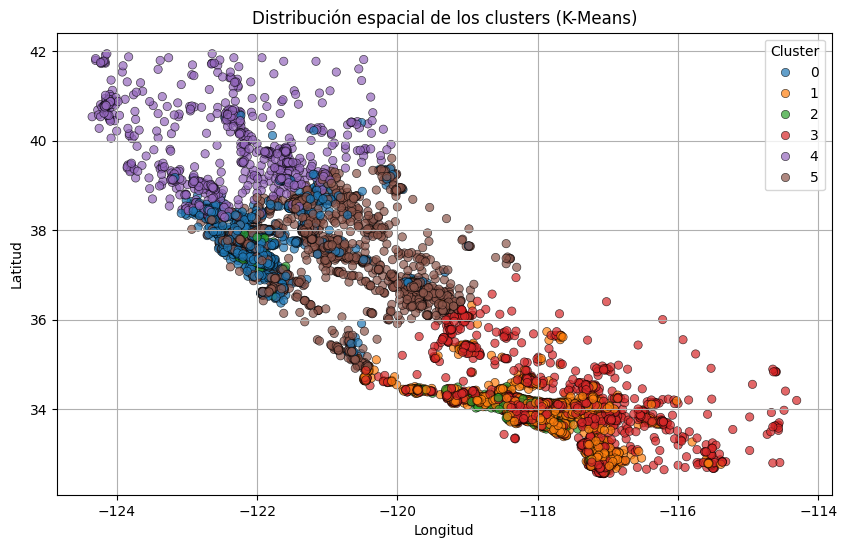

In [ ]:
# Gráfico usando las coordenadas geográficas
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=X_train_clustered,
    x='Longitude', y='Latitude',
    hue='cluster',
    palette='tab10',
    alpha=0.7,
    edgecolor='k'
)
plt.title('Distribución espacial de los clusters (K-Means)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

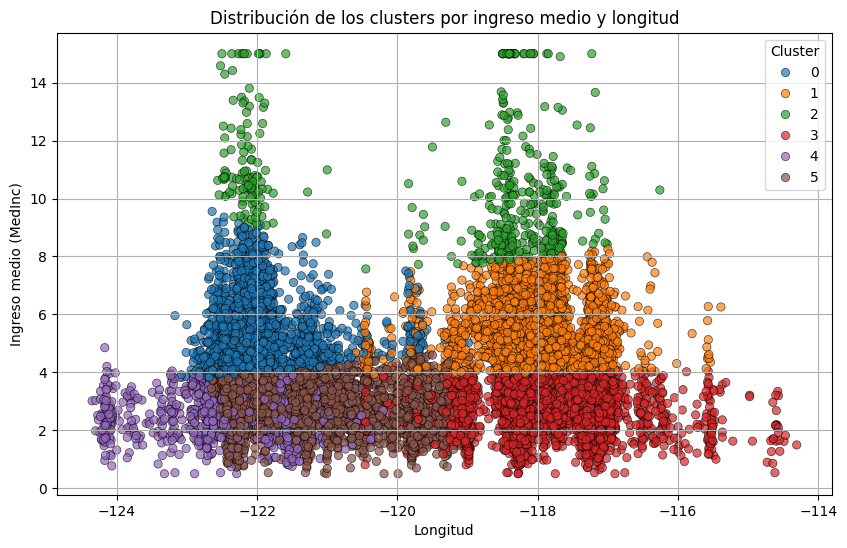

In [ ]:
# Gráfico usando MedInc vs Longitud
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=X_train_clustered,
    x='Longitude', y='MedInc',
    hue='cluster',
    palette='tab10',
    alpha=0.7,
    edgecolor='k'
)
plt.title('Distribución de los clusters por ingreso medio y longitud')
plt.xlabel('Longitud')
plt.ylabel('Ingreso medio (MedInc)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

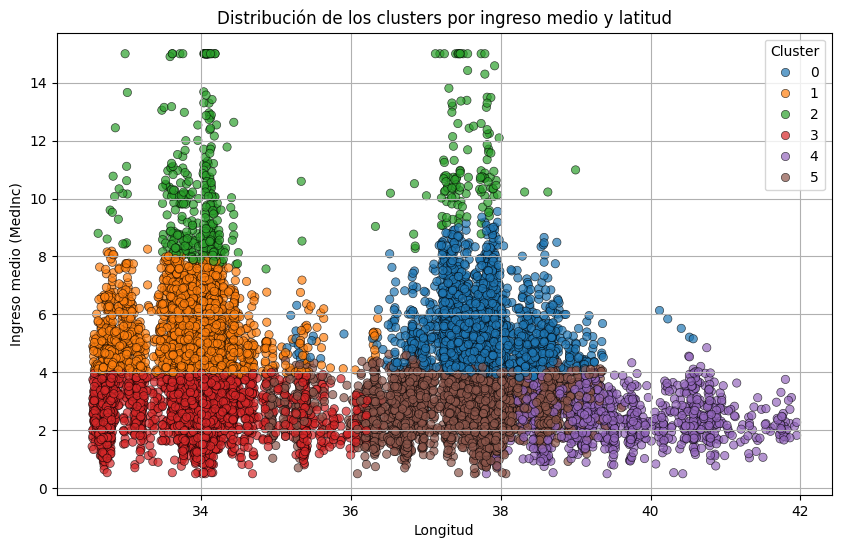

In [23]:
# Gráfico usando MedInc vs Latitud
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=X_train_clustered,
    x='Latitude', y='MedInc',
    hue='cluster',
    palette='tab10',
    alpha=0.7,
    edgecolor='k'
)
plt.title('Distribución de los clusters por ingreso medio y latitud')
plt.xlabel('Longitud')
plt.ylabel('Ingreso medio (MedInc)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

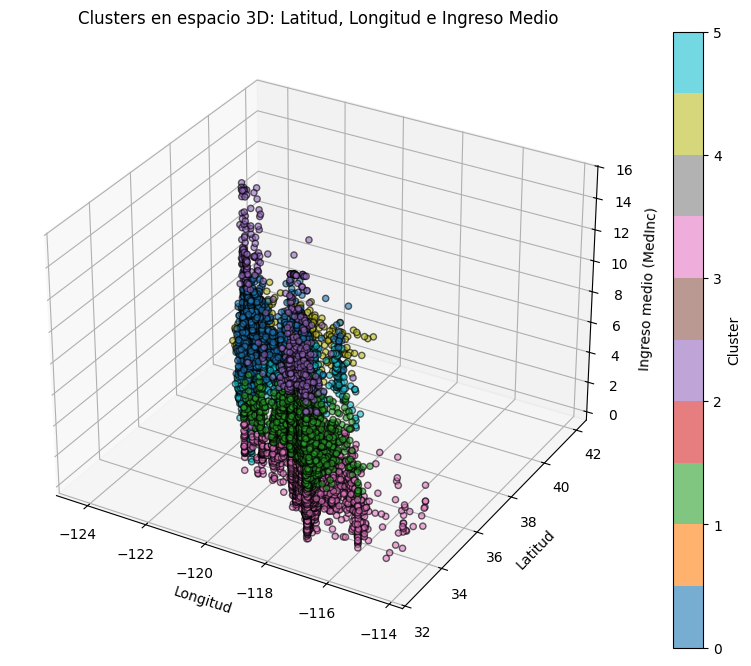

In [ ]:
# Crear gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Asignar valores a los ejes
sc = ax.scatter(
    X_train_clustered['Longitude'],
    X_train_clustered['Latitude'],
    X_train_clustered['MedInc'],
    c=X_train_clustered['cluster'],
    cmap='tab10',
    s=20,
    alpha=0.6,
    edgecolors='k'
)

# Etiquetas y título
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_zlabel('Ingreso medio (MedInc)')
ax.set_title('Clusters en espacio 3D: Latitud, Longitud e Ingreso Medio')

plt.colorbar(sc, ax=ax, label='Cluster')
plt.show()

## Predecir con el conjunto de pruebas

In [25]:
# Escalar los datos de prueba con el mismo scaler del entrenamiento
X_test_scaled = scaler.transform(X_test)

# Predecir los clusters en el conjunto de prueba
test_clusters = kmeans.predict(X_test_scaled)

# Añadir la columna 'cluster' al DataFrame de prueba
X_test_clustered = X_test.copy()
X_test_clustered['cluster'] = test_clusters

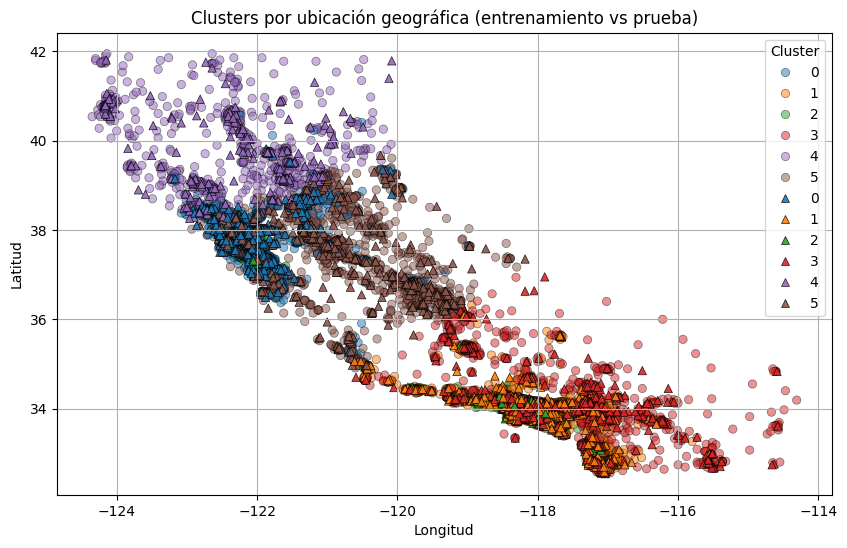

In [27]:
# Gráfico usando las coordenadas geográficas
plt.figure(figsize=(10, 6))

# Entrenamiento
sns.scatterplot(
    data=X_train_clustered,
    x='Longitude', y='Latitude',
    hue='cluster',
    palette='tab10',
    alpha=0.5,
    edgecolor='k'
)

# Prueba
sns.scatterplot(
    data=X_test_clustered,
    x='Longitude', y='Latitude',
    hue='cluster',
    palette='tab10',
    marker='^',
    alpha=0.9,
    edgecolor='k'
)

plt.title('Clusters por ubicación geográfica (entrenamiento vs prueba)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

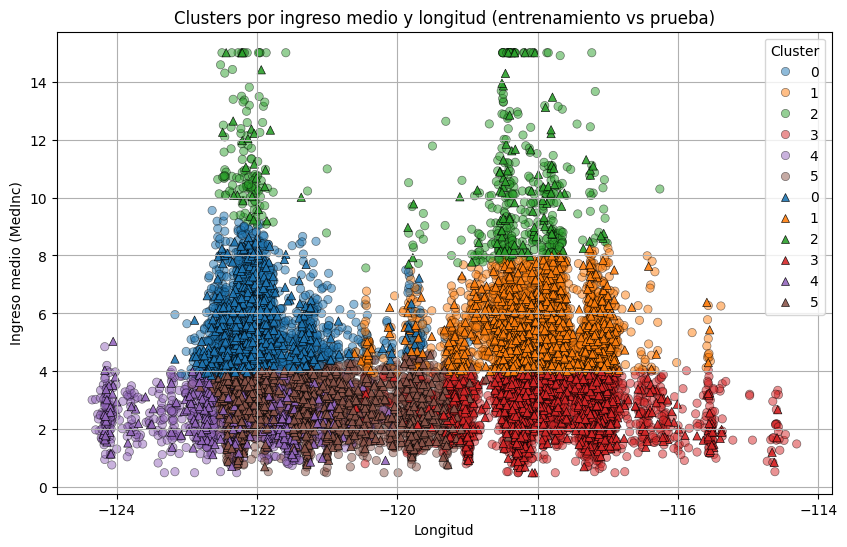

In [31]:
# Gráfico usando MedInc vs Longitud
plt.figure(figsize=(10, 6))

# Entrenamiento
sns.scatterplot(
    data=X_train_clustered,
    x='Longitude', y='MedInc',
    hue='cluster',
    palette='tab10',
    alpha=0.5,
    edgecolor='k'
)

# Prueba
sns.scatterplot(
    data=X_test_clustered,
    x='Longitude', y='MedInc',
    hue='cluster',
    palette='tab10',
    marker='^',
    alpha=0.9,
    edgecolor='k'
)

plt.title('Clusters por ingreso medio y longitud (entrenamiento vs prueba)')
plt.xlabel('Longitud')
plt.ylabel('Ingreso medio (MedInc)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

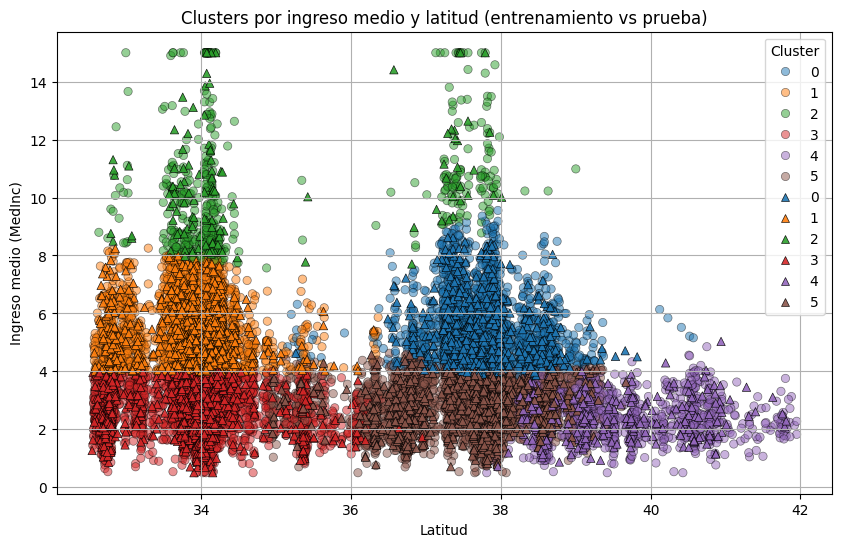

In [32]:
# Gráfico usando MedInc vs Latitud
plt.figure(figsize=(10, 6))

# Entrenamiento
sns.scatterplot(
    data=X_train_clustered,
    x='Latitude', y='MedInc',
    hue='cluster',
    palette='tab10',
    alpha=0.5,
    edgecolor='k'
)

# Prueba
sns.scatterplot(
    data=X_test_clustered,
    x='Latitude', y='MedInc',
    hue='cluster',
    palette='tab10',
    marker='^',
    alpha=0.9,
    edgecolor='k'
)

plt.title('Clusters por ingreso medio y latitud (entrenamiento vs prueba)')
plt.xlabel('Latitud')
plt.ylabel('Ingreso medio (MedInc)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


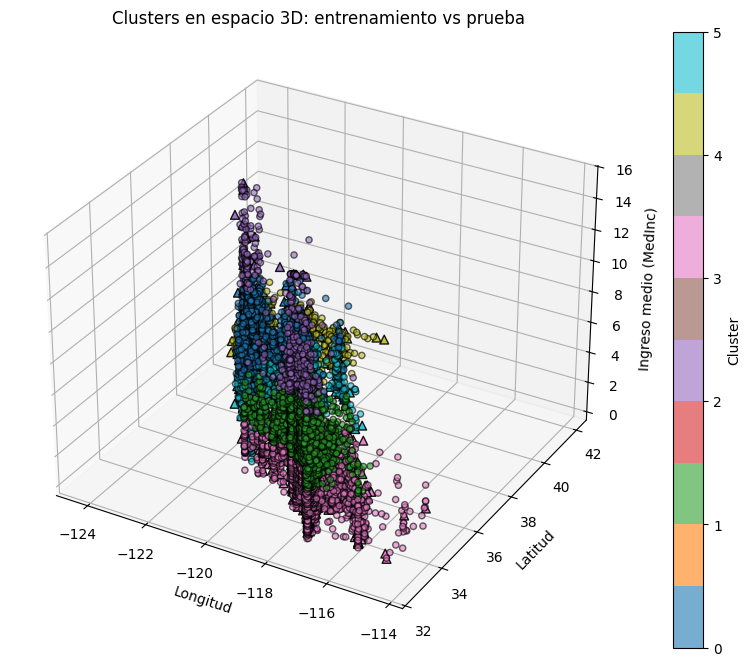

In [34]:
# Crear gráfico 3D con datos de entrenamiento y prueba
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Entrenamiento (círculos)
sc_train = ax.scatter(
    X_train_clustered['Longitude'],
    X_train_clustered['Latitude'],
    X_train_clustered['MedInc'],
    c=X_train_clustered['cluster'],
    cmap='tab10',
    s=20,
    alpha=0.6,
    edgecolors='k'
)

# Prueba (triángulos)
sc_test = ax.scatter(
    X_test_clustered['Longitude'],
    X_test_clustered['Latitude'],
    X_test_clustered['MedInc'],
    c=X_test_clustered['cluster'],
    cmap='tab10',
    marker='^',
    s=40,
    alpha=0.9,
    edgecolors='k'
)

# Etiquetas y leyenda
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_zlabel('Ingreso medio (MedInc)')
ax.set_title('Clusters en espacio 3D: entrenamiento vs prueba')

plt.colorbar(sc_train, ax=ax, label='Cluster')
plt.show()

## Guardar datasets con columna "cluster"

In [35]:
# Guardar datos de entrenamiento con cluster
X_train_clustered.to_csv('/workspaces/efrainnalmeida-k-means-project-tutorial/data/processed/train_with_clusters.csv', index=False)

# Guardar datos de prueba con cluster
X_test_clustered.to_csv('/workspaces/efrainnalmeida-k-means-project-tutorial/data/processed/test_with_clusters.csv', index=False)

## Modelo de clasificación supervisado

In [37]:
# Variables predictoras (X) y variable objetivo (y)
X_train_sup = X_train_clustered[['Latitude', 'Longitude', 'MedInc']]
y_train_sup = X_train_clustered['cluster']

X_test_sup = X_test_clustered[['Latitude', 'Longitude', 'MedInc']]
y_test_sup = X_test_clustered['cluster']

# Entrenar modelo
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_sup, y_train_sup)

# Predicciones
y_pred = clf.predict(X_test_sup)

# Evaluación
print("Reporte de clasificación:")
print(classification_report(y_test_sup, y_pred))

print("Matriz de confusión:")
print(confusion_matrix(y_test_sup, y_pred))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       557
           1       1.00      0.99      1.00       897
           2       0.99      0.98      0.99       116
           3       1.00      1.00      1.00      1397
           4       0.96      0.98      0.97       246
           5       0.99      0.98      0.99       915

    accuracy                           0.99      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       0.99      0.99      0.99      4128

Matriz de confusión:
[[ 554    0    0    0    3    0]
 [   0  892    1    2    0    2]
 [   1    1  114    0    0    0]
 [   0    2    0 1395    0    0]
 [   1    0    0    0  242    3]
 [   5    0    0    2    7  901]]


## 📊 Evaluación del modelo supervisado

Se entrenó un modelo de árbol de decisión para predecir el `cluster` generado previamente por K-Means, usando como variables `Latitude`, `Longitude` y `MedInc`. El modelo fue evaluado sobre el conjunto de prueba, obteniéndose los siguientes resultados:

### 📈 Reporte de clasificación

- **Exactitud global (accuracy):** 0.99 — indica una excelente capacidad del modelo para clasificar correctamente los datos.
- **Precisión, recall y F1-score** por clase son todos mayores a 0.96, lo que refleja un rendimiento muy equilibrado entre clases.
- El modelo no solo acierta con frecuencia, sino que **recupera casi todos los ejemplos verdaderos** de cada cluster.

### 📉 Matriz de confusión

La matriz muestra que los errores son mínimos:

- Solo hay **algunos errores dispersos entre clusters vecinos**, lo que podría deberse a **zonas limítrofes en el espacio geográfico** o **ingresos medios similares**.
- El cluster `3`, que parece tener más observaciones (`1397`), fue clasificado sin errores.
- El modelo cometió **ligeros errores en los clusters 4 y 5**, lo cual podría explorarse visualmente.

### ✅ Conclusión

El flujo no supervisado → supervisado ha funcionado exitosamente:

- K-Means permitió etiquetar automáticamente los datos.
- El modelo supervisado fue capaz de aprender esta estructura latente con altísima precisión.

Este enfoque sería útil si, por ejemplo, quisiéramos clasificar nuevas casas en clusters predefinidos sin ejecutar K-Means nuevamente.


## Guardar los modelos

In [40]:
# Definir ruta base
model_path = '/workspaces/efrainnalmeida-k-means-project-tutorial/models/'

# Guardar modelo K-Means
with open(model_path + 'kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Guardar clasificador supervisado (árbol de decisión)
with open(model_path + 'decision_tree_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)